In [27]:
import pandas as pd
import ir_datasets
from sklearn.metrics import cohen_kappa_score
from src.data import DATA_DIR_PROCESSED
import os

# Experiment 2: How good are LLM judgments on this dataset?
## Load generated and original qrels

In [ ]:
# load generated qrels
# generated_qrels_path = os.path.join(DATA_DIR_PROCESSED,"qrels-robust-Qwen-Qwen3-30B-A3B-Instruct-2507-FP8-robust-DNA-zero-shot-no-title-description.csv.gz")
# generated_qrels_path = os.path.join(DATA_DIR_PROCESSED, "qrels-robust-Qwen-Qwen3-30B-A3B-Instruct-2507-FP8-robust-DNA-zero-shot.csv.gz")
generated_qrels_path = os.path.join(DATA_DIR_PROCESSED, "qrels-robust-Qwen-Qwen3-14B-robust-DNA-zero-shot.csv.gz")

qrels_gen = pd.read_csv(generated_qrels_path, sep=" ", names=["query_id","doc_id", "relevance", "iteration"], dtype={"query_id": pd.CategoricalDtype(), "doc_id": pd.CategoricalDtype(), "relevance": float, "iteration": int})

In [29]:
# load original qrels for reference
dataset = ir_datasets.load("disks45/nocr/trec-robust-2004")
qrels = pd.DataFrame(dataset.qrels)
qrels["query_id"] = qrels["query_id"].astype("category")
qrels["doc_id"] = qrels["doc_id"].astype("category")

In [30]:
# merge generated with original qrels
qrels = qrels.merge(qrels_gen[["query_id", "doc_id", "relevance"]], on=["query_id","doc_id"], how="left", suffixes=('_orig', '_gen'))

In [31]:
# some documents were not judged in the generated qrels
print(f"Number of missing judgements in generated qrels: {qrels[qrels['relevance_gen'] == 999].shape[0]} of {len(qrels)}")
qrels = qrels[qrels['relevance_gen'] != 999]

Number of missing judgements in generated qrels: 195 of 311410


In [32]:
# Creqate binary relevance labels
qrels["relevance_gen"] = qrels["relevance_gen"].astype(int)
qrels["relevance_gen_bin"] = qrels["relevance_gen"]>0
qrels["relevance_orig_bin"] = qrels["relevance_orig"]>0

## Cohen kappa

In [33]:
print("Cohen kappa score for binary relevance:", cohen_kappa_score(qrels["relevance_orig_bin"], qrels["relevance_gen_bin"]))
print("Cohen kappa score for graded relevance:", cohen_kappa_score(qrels["relevance_orig"], qrels["relevance_gen"]))

Cohen kappa score for binary relevance: 0.4003125989040559
Cohen kappa score for graded relevance: 0.3347013226738521


## Per topic agreement

In [24]:
per_query_kappas = {}
for query in qrels.groupby("query_id"):
    per_query_kappas[query[0]] = cohen_kappa_score(query[1]["relevance_orig"], query[1]["relevance_gen"])

/tmp/ipykernel_962867/322099291.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for query in qrels.groupby("query_id"):


Text(0.5, 1.0, "Cohen's Kappa per Query\nbetween Original and Generated Relevance Judgments")

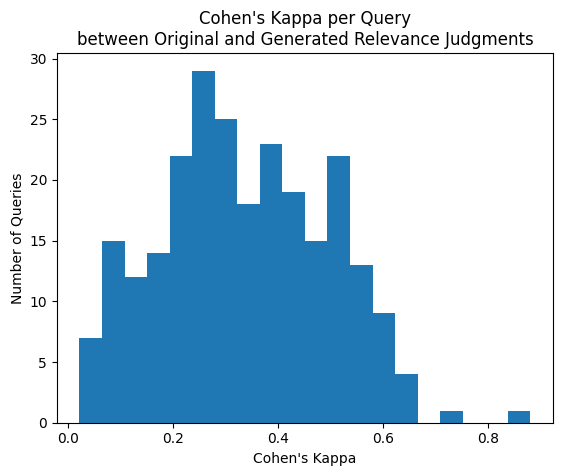

In [26]:
import matplotlib.pyplot as plt
plot = plt.hist(list(per_query_kappas.values()), bins=20)
plt.xlabel("Cohen's Kappa")
plt.ylabel("Number of Queries")
plt.title("Cohen's Kappa per Query\nbetween Original and Generated Relevance Judgments")